In [14]:
!pip install torch
!pip install matplotlib

  Using cached matplotlib-3.9.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.7-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-11.0.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.2.0-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.9.2-cp312-cp312-macosx_11_0_arm64.whl (7.8 MB)
Using cached contourpy-1.3.1-cp312-cp312-macosx_11_0_arm64.whl (255 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 6.9 MB/s eta 0:00:00a 0:00:01
Using cached kiwisolver-1.4.7-cp312-cp312-macosx_11_0_arm64.whl (63 kB)
Using cached pillow-11.0.0-cp312-cp312-macosx_11_0_arm64.whl (3.0 MB)
Using cached pyparsing-3.2.0-py3-none-any.whl (106 kB)


In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import sys
sys.path.append('..')

In [4]:
from src.data.dataset import MagnetIterator
import tqdm

In [7]:
from src.data.grid import MagnetGridIterator
iterator = MagnetGridIterator(
    "../data/processed/batch_6/grid_voxel_size_4_data_type_float32",
    phase_samples_per_simulation=2,
)

In [16]:
import torch
def worker_init_fn(worker_id):
     worker_info = torch.utils.data.get_worker_info()
     dataset = worker_info.dataset  # the dataset copy in this worker process
     overall_simulations = dataset.simulation_list
     num_workers = worker_info.num_workers

     # configure the dataset to only process the split workload
     worker_id = worker_info.id
     worker_simulations = overall_simulations[worker_id::num_workers]
     dataset.simulation_list = worker_simulations

In [10]:
from torch.utils.data import DataLoader
import numpy as np
dl = DataLoader(iterator, batch_size=1, num_workers=2)

In [22]:
item = next(iter(dl))

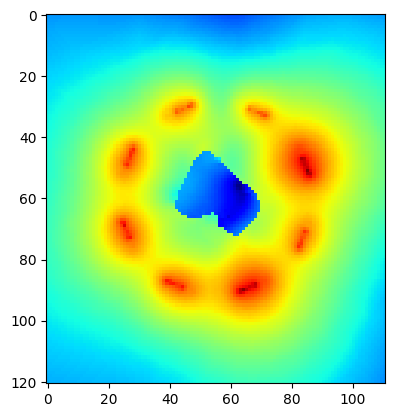

In [23]:
import matplotlib.pyplot as plt
import numpy as np

re = item['field'][0, 0, 0, :, :, :, :]
im = item['field'][0, 0, 1, :, :, :, :]

result = torch.norm(torch.complex(re, im), dim=0)

plt.imshow(result[:, :, 35].cpu().numpy(), cmap='jet', norm='log')
plt.show()